# 09 — Transport Entrances Exploration

Investigates why some transport stops — particularly S-tog train stations near the southern
canal — are under-represented in the CitySeer accessibility analysis (notebook 08).

## Problems diagnosed in notebook 08

1. **Centroid placement**: Nørreport (train + metro) has its centroid ~688m outside the
   Nørrebro boundary, placed at the underground platform center. Its street-level exits
   are spread much closer to Nørrebro.
2. **Single point per station**: Large multi-exit stations are represented by one point.
   Accessibility is underestimated for buildings near secondary exits.
3. **Bus is OK**: Street-level bus stops have centroids close to the actual boarding point.

## This notebook

- Fetches OSM `railway=subway_entrance` for metro access points
- Fetches OSM S-tog station entrance nodes
- Compares OSM entrance coverage against existing stop centroids
- Visualises gaps and validates spatial plausibility
- Decides what to carry forward to a processing script

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box

from src.utils.config import (
    TRANSPORT_STOPS_OUTPUT,
    NORREBRO_BOUNDARY_FILE,
    NORREBRO_BOUNDARY_LAYER,
    PEDESTRIAN_NETWORK_GPKG,
)

# Study area
boundary = gpd.read_file(NORREBRO_BOUNDARY_FILE, layer=NORREBRO_BOUNDARY_LAYER)
boundary_wgs84 = boundary.to_crs(4326)
boundary_25832 = boundary.to_crs(25832)

# 1 km buffer around boundary for OSM queries — needed to capture Nørreport exits
boundary_1km = boundary_25832.buffer(1000).to_crs(4326)
bounds_1km = boundary_1km.total_bounds  # [minx, miny, maxx, maxy] WGS84

# Existing stops
stops = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="stops").to_crs(25832)
stops_wgs84 = stops.to_crs(4326)

print(f"Boundary WGS84 bounds: {boundary_wgs84.total_bounds.round(5)}")
print(f"1km buffer WGS84 bounds: {bounds_1km.round(5)}")
print(f"\nExisting stops: {len(stops):,}")
print(stops["transport_mode"].value_counts())

Boundary WGS84 bounds: [12.53476 55.6815  12.56939 55.71142]
1km buffer WGS84 bounds: [12.51887 55.67252 12.58527 55.7204 ]

Existing stops: 2,687
transport_mode
bus      2581
train      62
metro      44
Name: count, dtype: int64


## 1. Existing stop centroids — where are they?

Map the non-bus stops against the boundary to see which are inside/nearby vs distant.

In [2]:
# Filter to rail/metro stops within 1km of boundary
buf_1km_25832 = boundary_25832.buffer(1000).union_all()
rail_stops = stops[
    stops["transport_mode"].isin(["train", "metro"]) & stops.within(buf_1km_25832)
].copy()

# Distance to boundary for each
boundary_union = boundary_25832.union_all()
rail_stops["dist_to_boundary"] = rail_stops.geometry.apply(
    lambda g: (
        round(g.distance(boundary_union), 0) if not boundary_union.contains(g) else 0.0
    )
)
rail_stops["inside_boundary"] = rail_stops.geometry.within(boundary_union)

print(
    rail_stops[["stop_name", "transport_mode", "inside_boundary", "dist_to_boundary"]]
    .sort_values(["transport_mode", "dist_to_boundary"])
    .to_string()
)

                               stop_name transport_mode  inside_boundary  dist_to_boundary
2515             Nuuks Plads St. (Metro)          metro             True               0.0
2516       Nørrebros Runddel St. (Metro)          metro             True               0.0
2517                Nørrebro St. (Metro)          metro             True               0.0
2518           Skjolds Plads St. (Metro)          metro             True               0.0
2519       Vibenshus Runddel St. (Metro)          metro            False              67.0
39                     Forum St. (Metro)          metro            False              83.0
2514      Aksel Møllers Have St. (Metro)          metro            False             476.0
41                 Nørreport St. (Metro)          metro            False             623.0
2521               Trianglen St. (Metro)          metro            False             864.0
2520  Poul Henningsens Plads St. (Metro)          metro            False             922.0

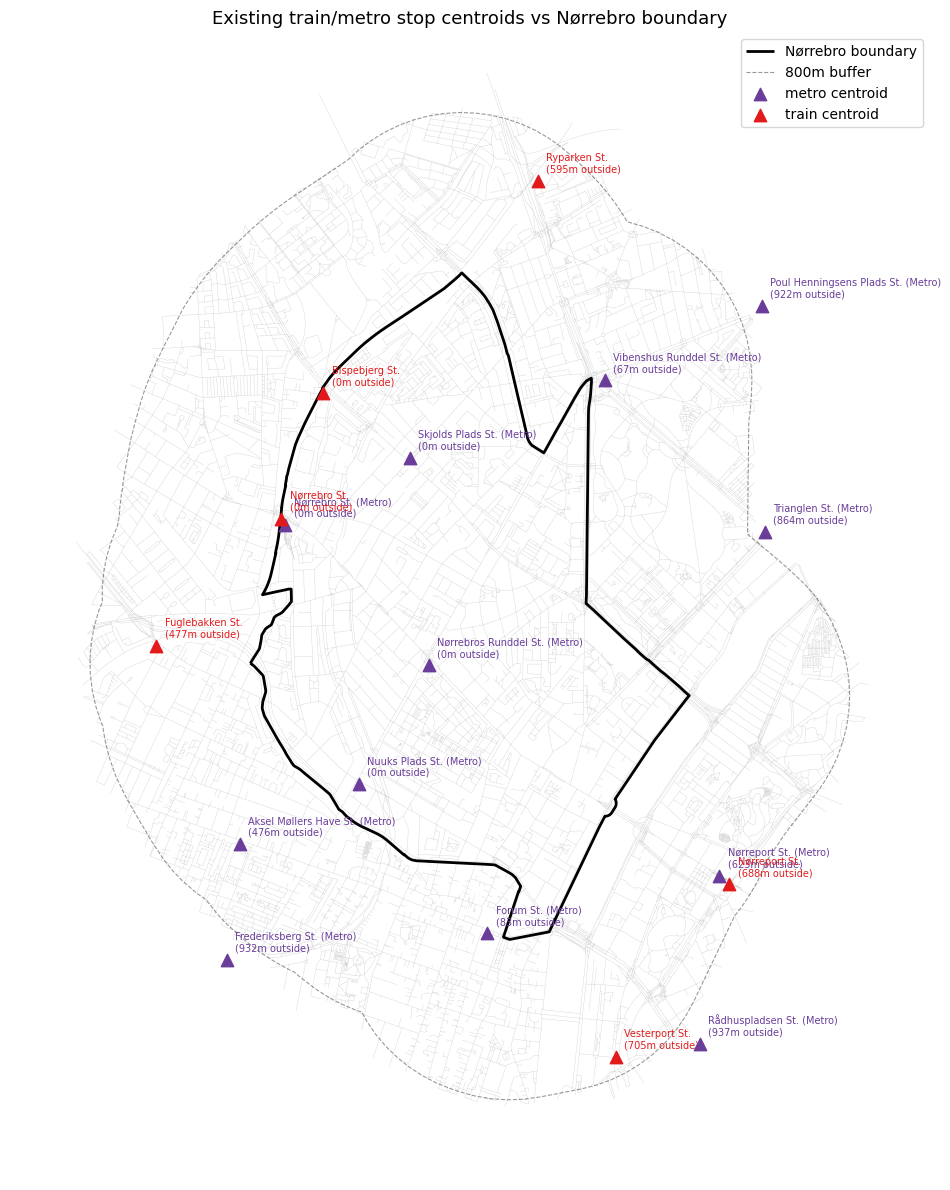

In [3]:
# Overview map: boundary + rail stops, colour by mode
edges = gpd.read_file(PEDESTRIAN_NETWORK_GPKG, layer="edges").to_crs(25832)
bbox = boundary_25832.buffer(1200).total_bounds

fig, ax = plt.subplots(figsize=(12, 12))

edges.plot(ax=ax, linewidth=0.3, color="#aaaaaa", alpha=0.5)
boundary_25832.boundary.plot(
    ax=ax, color="black", linewidth=2, label="Nørrebro boundary"
)
boundary_25832.buffer(800).boundary.plot(
    ax=ax, color="black", linewidth=0.8, linestyle="--", alpha=0.4, label="800m buffer"
)

colors = {"train": "#e31a1c", "metro": "#6a3d9a"}
for mode, grp in rail_stops.groupby("transport_mode"):
    grp.plot(
        ax=ax,
        color=colors[mode],
        markersize=80,
        marker="^",
        label=f"{mode} centroid",
        zorder=5,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"{row['stop_name']}\n({int(row['dist_to_boundary'])}m outside)",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=7,
            color=colors[mode],
        )

ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
ax.set_title("Existing train/metro stop centroids vs Nørrebro boundary", fontsize=13)
ax.legend(loc="upper right")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2. Fetch OSM metro subway entrances

OSM tags street-level access points to underground stations with `railway=subway_entrance`.
Each entrance node represents a physical stairway or escalator at street level.
We query within the 1km boundary buffer to capture Nørreport exits.

In [4]:
# Build a Shapely polygon from the 1km WGS84 buffer for the OSM query
poly_1km = boundary_1km.union_all()

# Fetch subway entrance nodes from OSM
print("Fetching railway=subway_entrance from OSM...")
try:
    gdf_subway_entrances = ox.features_from_polygon(
        poly_1km,
        tags={"railway": "subway_entrance"},
    )
    print(f"Subway entrances: {len(gdf_subway_entrances):,}")
    print(
        f"Geometry types: {gdf_subway_entrances.geometry.geom_type.value_counts().to_dict()}"
    )
    print(f"Columns: {gdf_subway_entrances.columns.tolist()}")
except Exception as e:
    print(f"Error: {e}")

Fetching railway=subway_entrance from OSM...
Subway entrances: 25
Geometry types: {'Point': 25}
Columns: ['geometry', 'railway', 'wheelchair', 'entrance', 'door', 'level', 'name', 'public_transport', 'fee', 'handrail', 'highway', 'layer']


In [5]:
# Inspect available attributes
useful_cols = [
    c for c in gdf_subway_entrances.columns if gdf_subway_entrances[c].notna().sum() > 0
]
print("Non-empty columns:")
for col in useful_cols:
    n_unique = gdf_subway_entrances[col].nunique()
    sample = (
        gdf_subway_entrances[col].dropna().iloc[0]
        if gdf_subway_entrances[col].notna().any()
        else None
    )
    print(f"  {col}: {n_unique} unique | sample: {sample}")

Non-empty columns:
  geometry: 25 unique | sample: POINT (12.5702248 55.6838458)
  railway: 1 unique | sample: subway_entrance
  wheelchair: 2 unique | sample: no
  entrance: 2 unique | sample: main
  door: 2 unique | sample: no
  level: 1 unique | sample: 0
  name: 2 unique | sample: Vibenhus Runddel
  public_transport: 1 unique | sample: entrance
  fee: 1 unique | sample: no
  handrail: 1 unique | sample: yes
  highway: 1 unique | sample: elevator
  layer: 1 unique | sample: -2


In [6]:
# Extract point geometries only (some features may return as polygons for station areas)
metro_entrances = gdf_subway_entrances[
    gdf_subway_entrances.geometry.geom_type == "Point"
].copy()
metro_entrances = metro_entrances.to_crs(25832)
metro_entrances = metro_entrances.reset_index()  # OSM id in index

# Keep useful columns
keep_cols = ["osmid", "name", "geometry"]
for col in ["ref", "network", "operator", "wheelchair"]:
    if col in metro_entrances.columns:
        keep_cols.append(col)
metro_entrances = metro_entrances[
    [c for c in keep_cols if c in metro_entrances.columns]
]

metro_entrances["inside_boundary"] = metro_entrances.geometry.within(
    boundary_25832.union_all()
)
metro_entrances["dist_to_boundary"] = metro_entrances.geometry.apply(
    lambda g: (
        round(g.distance(boundary_25832.union_all()), 0)
        if not boundary_25832.union_all().contains(g)
        else 0.0
    )
)

print(f"Metro entrance points: {len(metro_entrances):,}")
print(f"Inside Nørrebro boundary: {metro_entrances['inside_boundary'].sum()}")
print(f"Within 1km of boundary: {len(metro_entrances):,}")
print("\nAll metro entrances:")
print(metro_entrances[["name", "inside_boundary", "dist_to_boundary"]].to_string())

Metro entrance points: 25
Inside Nørrebro boundary: 8
Within 1km of boundary: 25

All metro entrances:
                name  inside_boundary  dist_to_boundary
0                NaN            False             581.0
1                NaN            False             654.0
2                NaN            False              38.0
3                NaN            False             753.0
4                NaN            False             701.0
5                NaN            False             702.0
6                NaN            False             739.0
7                NaN            False             690.0
8                NaN            False             693.0
9                NaN            False             920.0
10               NaN            False             866.0
11               NaN            False             962.0
12               NaN            False             887.0
13               NaN            False             800.0
14               NaN             True               0.0
1

## 3. Fetch OSM S-tog / train station entrances

S-tog stations are above-ground, but the stop centroid may be placed at the platform center
rather than the street-side entrance gates. We query OSM for station-level entrance nodes.

In [7]:
# Fetch railway station areas and their entrance nodes
print("Fetching railway=station (train/S-tog) from OSM...")
try:
    gdf_stations = ox.features_from_polygon(
        poly_1km,
        tags={"railway": "station"},
    )
    print(f"Railway stations: {len(gdf_stations):,}")
    print(f"Geometry types: {gdf_stations.geometry.geom_type.value_counts().to_dict()}")
    # Show names and network/operator
    name_cols = [
        c
        for c in ["name", "network", "operator", "railway"]
        if c in gdf_stations.columns
    ]
    print(gdf_stations[name_cols].to_string())
except Exception as e:
    print(f"Error: {e}")

Fetching railway=station (train/S-tog) from OSM...
Railway stations: 12
Geometry types: {'Point': 12}
                                      name network            operator  railway
element id                                                                     
node    5715956180                   Forum   Metro                 NaN  station
        5715956181           Frederiksberg   Metro                 NaN  station
        6836386877           Rådhuspladsen   Metro                 NaN  station
        6836446142       Nørrebros Runddel   Metro                 NaN  station
        6836446143                Nørrebro   Metro                 NaN  station
        6836446144      Aksel Møllers Have   Metro                 NaN  station
        6836446145             Nuuks Plads   Metro  Metroselskabet I/S  station
        6836466111           Skjolds Plads   Metro                 NaN  station
        6836624243        Vibenhus Runddel   Metro                 NaN  station
        6836652392

In [8]:
# Also fetch entrance nodes tagged on station buildings
print("Fetching entrance=main/yes near stations from OSM...")
try:
    gdf_entrances_osm = ox.features_from_polygon(
        poly_1km,
        tags={"entrance": True},
    )
    # Filter to nodes only (not ways/relations)
    gdf_entrances_osm = gdf_entrances_osm[
        gdf_entrances_osm.geometry.geom_type == "Point"
    ].copy()
    print(f"Entrance nodes: {len(gdf_entrances_osm):,}")
    print(
        f"entrance values: {gdf_entrances_osm['entrance'].value_counts().head(10).to_dict()}"
    )
except Exception as e:
    print(f"Error: {e}")

Fetching entrance=main/yes near stations from OSM...
Entrance nodes: 332
entrance values: {'yes': 213, 'main': 76, 'service': 15, 'staircase': 9, 'emergency': 7, 'exit': 3, 'home': 3, 'shop': 2, 'gate': 2, 'basement': 2}


In [9]:
# Fetch public_transport=stop_position with railway tag — more precise than stop_area centroid
print("Fetching public_transport=stop_position (railway) from OSM...")
try:
    gdf_stop_pos = ox.features_from_polygon(
        poly_1km,
        tags={"public_transport": "stop_position", "railway": True},
    )
    gdf_stop_pos = gdf_stop_pos[gdf_stop_pos.geometry.geom_type == "Point"].copy()
    print(f"Stop positions: {len(gdf_stop_pos):,}")
    name_cols = [
        c
        for c in ["name", "railway", "network", "operator"]
        if c in gdf_stop_pos.columns
    ]
    print(
        gdf_stop_pos[name_cols].value_counts(["railway"]).head(10)
        if "railway" in gdf_stop_pos.columns
        else "no railway column"
    )
    print(gdf_stop_pos[name_cols].head(20).to_string())
except Exception as e:
    print(f"Error: {e}")

Fetching public_transport=stop_position (railway) from OSM...
Stop positions: 312
railway         
switch              51
stop                42
subway_entrance     25
station             12
halt                 7
railway_crossing     5
defect_detector      2
buffer_stop          1
site                 1
Name: count, dtype: int64
                              name railway network operator
element id                                                 
node    21701643         Nørreport    stop     NaN      NaN
        21701665             Forum    stop   Metro      NaN
        21701666     Frederiksberg    stop   Metro      NaN
        24960728        Bispebjerg    halt   S-tog      NaN
        24960735          Nørrebro    stop     NaN      NaN
        24960745       Fuglebakken    stop     NaN      NaN
        24971120               NaN  switch     NaN      NaN
        25389793         Nørreport    stop     NaN      NaN
        25876589               NaN  switch     NaN      NaN
        

## 4. Visualise: centroids vs OSM entrances per station

Side-by-side comparison for key stations: Nørreport, Metro M2/M3 stops inside Nørrebro.

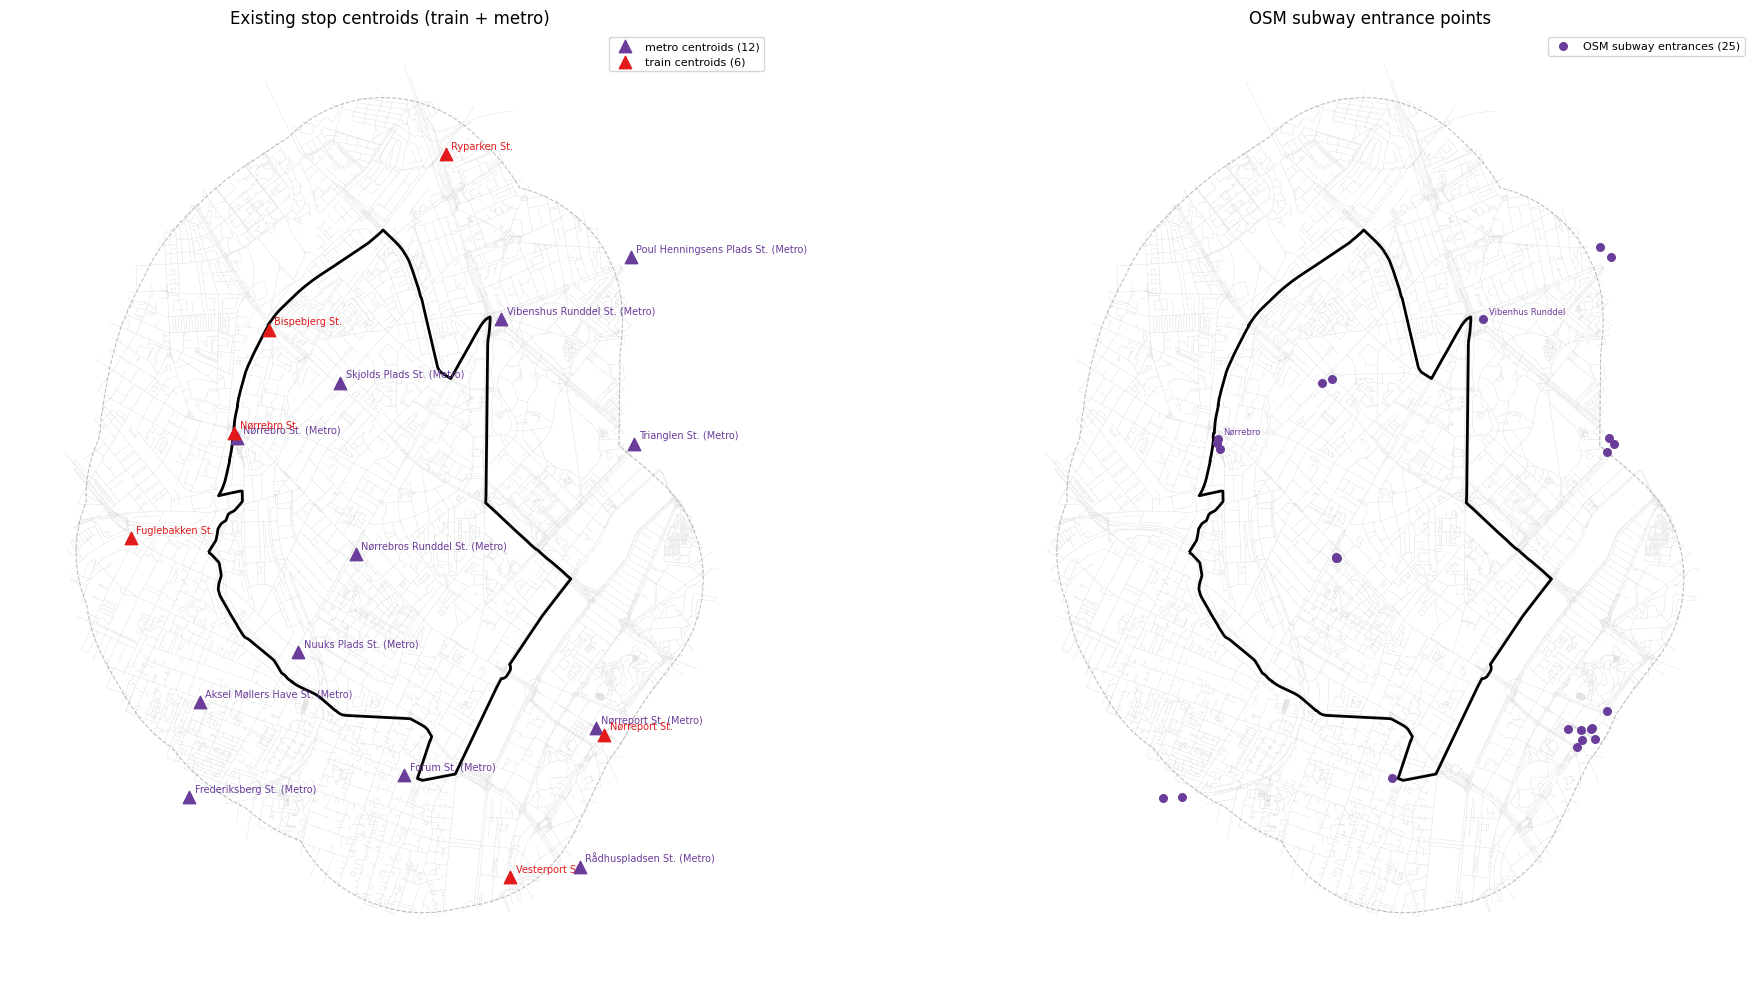

In [10]:
# Full overview: boundary + existing centroids + OSM subway entrances
metro_entrances_plot = (
    metro_entrances.copy() if "metro_entrances" in dir() else gpd.GeoDataFrame()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, title, show_entrances in [
    (axes[0], "Existing stop centroids (train + metro)", False),
    (axes[1], "OSM subway entrance points", True),
]:
    edges.plot(ax=ax, linewidth=0.3, color="#cccccc", alpha=0.7)
    boundary_25832.boundary.plot(ax=ax, color="black", linewidth=2)
    boundary_25832.buffer(800).boundary.plot(
        ax=ax, color="gray", linewidth=0.8, linestyle="--", alpha=0.5
    )

    if show_entrances and len(metro_entrances_plot) > 0:
        metro_entrances_plot.plot(
            ax=ax,
            color="#6a3d9a",
            markersize=30,
            marker="o",
            zorder=5,
            label=f"OSM subway entrances ({len(metro_entrances_plot)})",
        )
        for _, row in metro_entrances_plot.iterrows():
            if pd.notna(row.get("name")):
                ax.annotate(
                    row["name"],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=6,
                    color="#6a3d9a",
                )
    else:
        # Show existing centroids
        for mode, grp in rail_stops.groupby("transport_mode"):
            grp.plot(
                ax=ax,
                color=colors[mode],
                markersize=80,
                marker="^",
                label=f"{mode} centroids ({len(grp)})",
                zorder=5,
            )
            for _, row in grp.iterrows():
                ax.annotate(
                    row["stop_name"],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=7,
                    color=colors[mode],
                )

    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_title(title, fontsize=12)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

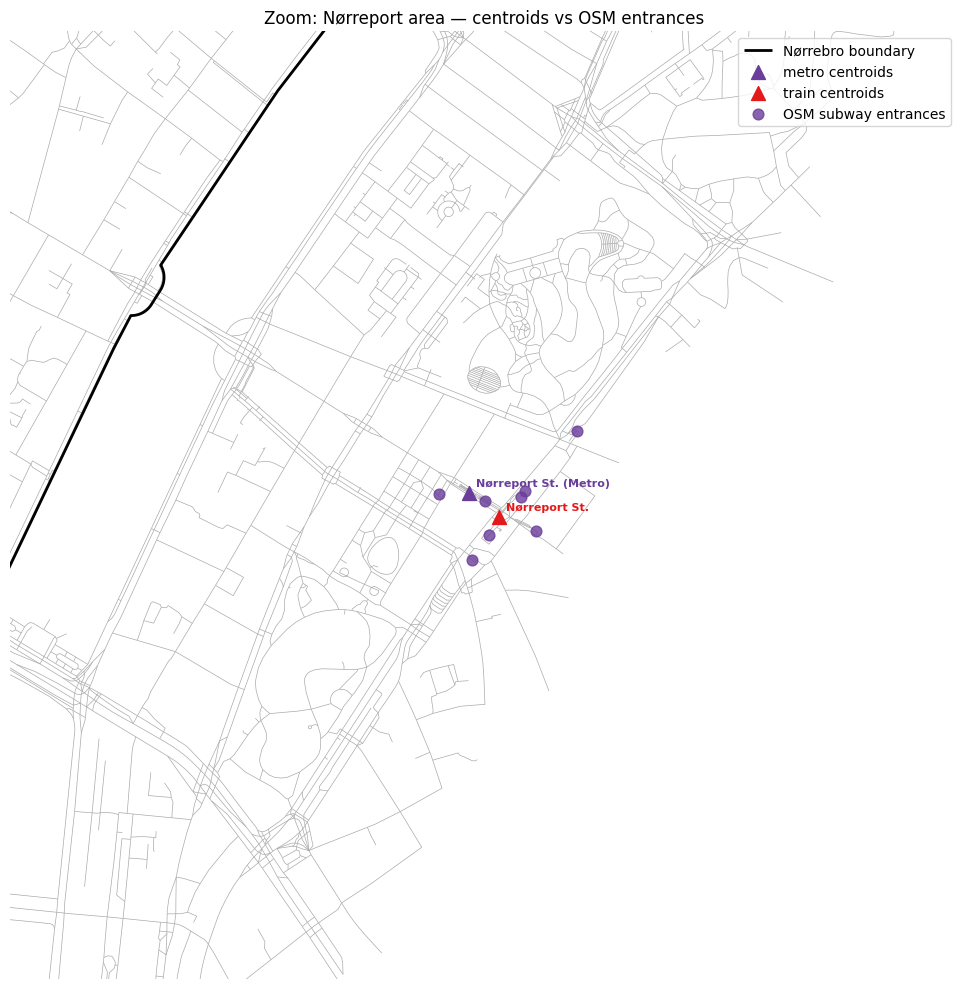

In [11]:
# Zoom in on Nørreport — the most problematic station
# Find Nørreport centroid
norr_centroid = rail_stops[rail_stops["stop_name"].str.contains("Nørreport")]
if len(norr_centroid) > 0:
    cx = norr_centroid.geometry.x.mean()
    cy = norr_centroid.geometry.y.mean()
    zoom = 800

    fig, ax = plt.subplots(figsize=(10, 10))
    edges.plot(ax=ax, linewidth=0.5, color="#aaaaaa")
    boundary_25832.boundary.plot(
        ax=ax, color="black", linewidth=2, label="Nørrebro boundary"
    )

    # Existing centroids
    for mode, grp in rail_stops.groupby("transport_mode"):
        grp.plot(
            ax=ax,
            color=colors[mode],
            markersize=100,
            marker="^",
            label=f"{mode} centroids",
            zorder=5,
        )
        for _, row in grp.iterrows():
            ax.annotate(
                row["stop_name"],
                xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                color=colors[mode],
                fontweight="bold",
            )

    # OSM subway entrances
    if len(metro_entrances_plot) > 0:
        metro_entrances_plot.plot(
            ax=ax,
            color="#6a3d9a",
            markersize=60,
            marker="o",
            label=f"OSM subway entrances",
            zorder=6,
            alpha=0.8,
        )
        for _, row in metro_entrances_plot.iterrows():
            name = row.get("name", "")
            if pd.notna(name) and name:
                ax.annotate(
                    name,
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(4, -10),
                    textcoords="offset points",
                    fontsize=6,
                    color="#6a3d9a",
                )

    ax.set_xlim(cx - zoom, cx + zoom)
    ax.set_ylim(cy - zoom, cy + zoom)
    ax.set_title("Zoom: Nørreport area — centroids vs OSM entrances", fontsize=12)
    ax.legend(loc="upper right")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print("Nørreport not found in rail_stops")

## 5. Coverage comparison: which stations have OSM entrances?

Map each known stop (from existing data) to its nearest OSM entrance(s) and check
whether they are better placed for accessibility analysis.

In [12]:
if len(metro_entrances_plot) > 0:
    # For each OSM entrance, find nearest existing stop centroid to identify which station it belongs to
    from sklearn.neighbors import BallTree
    import numpy as np

    centroids_xy = np.array([[g.x, g.y] for g in rail_stops.geometry])
    entrances_xy = np.array([[g.x, g.y] for g in metro_entrances_plot.geometry])

    # BallTree uses radians for haversine, but we're in EPSG:25832 (metres) — use euclidean
    from sklearn.neighbors import KDTree

    tree = KDTree(centroids_xy)
    dists, idxs = tree.query(entrances_xy, k=1)

    metro_entrances_plot = metro_entrances_plot.copy()
    metro_entrances_plot["nearest_stop"] = rail_stops.iloc[idxs.flatten()][
        "stop_name"
    ].values
    metro_entrances_plot["dist_to_centroid"] = dists.flatten().round(0)

    print("OSM entrance → nearest stop centroid:")
    print(
        metro_entrances_plot[
            ["name", "nearest_stop", "dist_to_centroid", "dist_to_boundary"]
        ]
        .sort_values("nearest_stop")
        .to_string()
    )

    print("\nEntrance count per station:")
    print(
        metro_entrances_plot.groupby("nearest_stop")["dist_to_centroid"].agg(
            ["count", "min", "max"]
        )
    )
else:
    print("No metro entrances fetched — check cell 6")

OSM entrance → nearest stop centroid:
                name                        nearest_stop  dist_to_centroid  dist_to_boundary
2                NaN                   Forum St. (Metro)              45.0              38.0
11               NaN           Frederiksberg St. (Metro)              39.0             962.0
12               NaN           Frederiksberg St. (Metro)              71.0             887.0
17               NaN                Nørrebro St. (Metro)              32.0               0.0
18          Nørrebro                Nørrebro St. (Metro)               5.0               0.0
19               NaN                Nørrebro St. (Metro)              65.0               0.0
22               NaN       Nørrebros Runddel St. (Metro)              22.0               0.0
23               NaN       Nørrebros Runddel St. (Metro)              22.0               0.0
24               NaN       Nørrebros Runddel St. (Metro)              16.0               0.0
3                NaN            

## 6. Check S-tog station entrance geometry

S-tog stops are above-ground. The key question: does the OSM station polygon give
us usable entrance points, or are the stop_position nodes close enough already?

In [13]:
# Fetch railway=halt (S-tog minor stops) and railway=station in detail
print("Fetching S-tog specific features from OSM...")
try:
    gdf_stog = ox.features_from_polygon(
        poly_1km,
        tags={"railway": ["halt", "station"], "network": "S-tog"},
    )
    print(f"S-tog features: {len(gdf_stog)}")
    name_cols = [
        c
        for c in ["name", "railway", "network", "operator", "ref"]
        if c in gdf_stog.columns
    ]
    print(gdf_stog[name_cols].to_string())
except Exception as e:
    print(f"S-tog query error: {e}")

# Fallback: just get all railway nodes within the area
print("\nFetching all railway=* nodes for overview...")
try:
    gdf_railway_nodes = ox.features_from_polygon(
        poly_1km,
        tags={"railway": True},
    )
    gdf_railway_nodes = gdf_railway_nodes[
        gdf_railway_nodes.geometry.geom_type == "Point"
    ].copy()
    print(f"Railway point nodes: {len(gdf_railway_nodes)}")
    if "railway" in gdf_railway_nodes.columns:
        print(gdf_railway_nodes["railway"].value_counts().head(20))
except Exception as e:
    print(f"Error: {e}")

Fetching S-tog specific features from OSM...
S-tog features: 19
                                      name  railway network            operator      ref
element id                                                                              
node    24960728                Bispebjerg     halt   S-tog                 NaN      NaN
        593753668               Vesterport     halt   S-tog                 NaN      NaN
        593869905                 Ryparken     halt     NaN                 NaN      NaN
        610619173                 Nørrebro     halt     NaN                 NaN      NaN
        611297799              Fuglebakken     halt   S-tog           DSB S-tog      NaN
        4993155222               Nørreport     halt     NaN                 NaN  8600646
        5715956180                   Forum  station   Metro                 NaN      NaN
        5715956181           Frederiksberg  station   Metro                 NaN      NaN
        6836386877           Rådhuspladsen  st

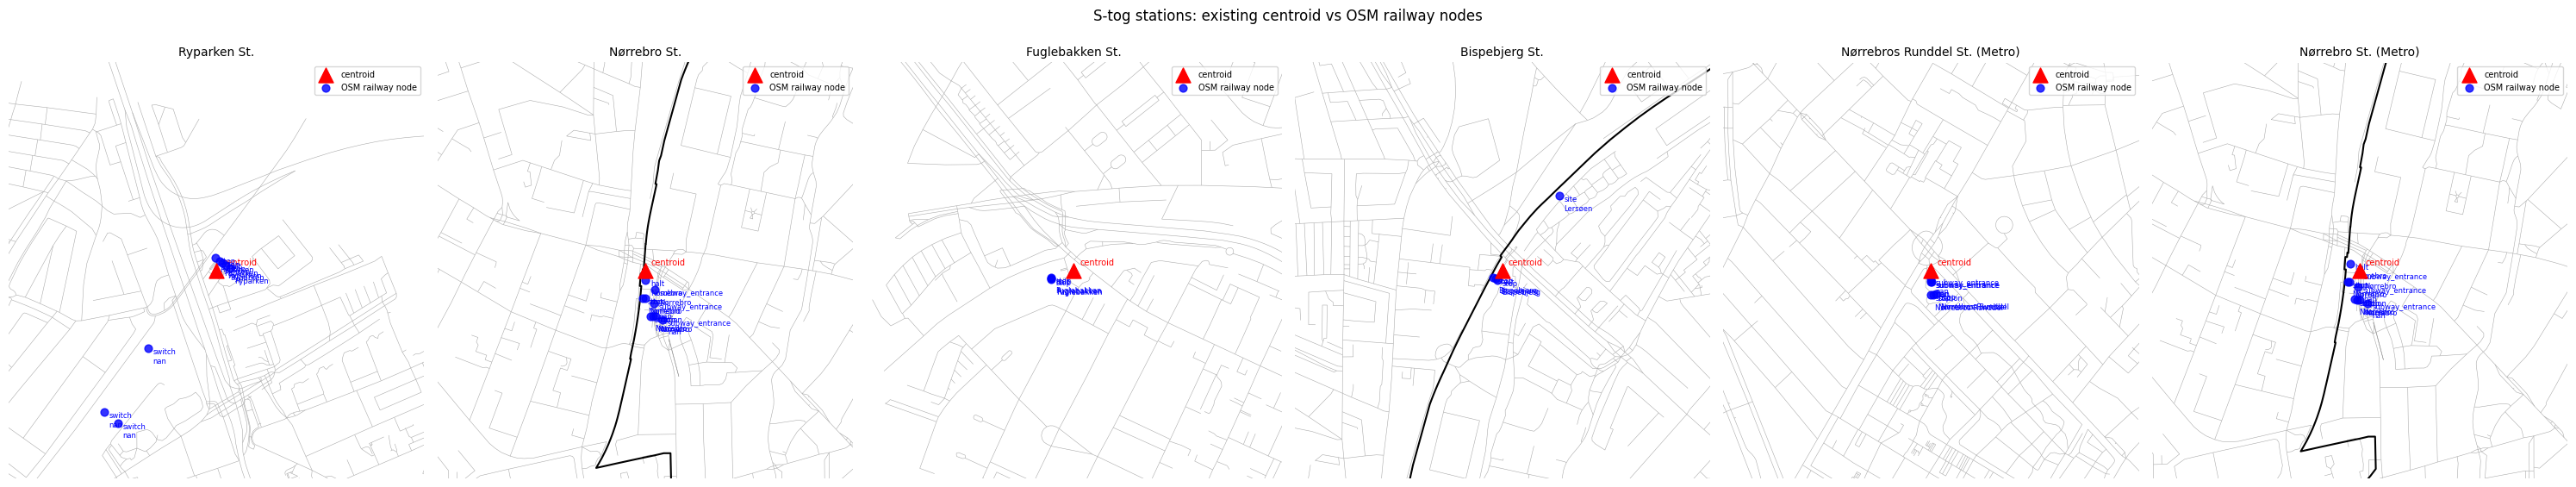

In [14]:
# Per-station zoom: Ryparken, Nørrebro St, Bispebjerg — do OSM points match?
stog_names = ["Ryparken", "Nørrebro", "Bispebjerg", "Fuglebakken"]
stog_stops = rail_stops[
    rail_stops["stop_name"].str.contains("|".join(stog_names), na=False)
]

n = len(stog_stops)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]

    zoom = 400
    for ax, (_, stop) in zip(axes, stog_stops.iterrows()):
        cx, cy = stop.geometry.x, stop.geometry.y
        edges.plot(ax=ax, linewidth=0.4, color="#aaaaaa")
        boundary_25832.boundary.plot(ax=ax, color="black", linewidth=1.5)

        # Existing centroid
        ax.scatter([cx], [cy], c="red", s=150, zorder=6, marker="^", label="centroid")
        ax.annotate(
            "centroid",
            xy=(cx, cy),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=7,
            color="red",
        )

        # OSM railway nodes near this stop
        if "gdf_railway_nodes" in dir() and len(gdf_railway_nodes) > 0:
            nearby_railway = gdf_railway_nodes.to_crs(25832).copy()
            nearby_railway = nearby_railway[
                nearby_railway.distance(stop.geometry) < 400
            ]
            if len(nearby_railway) > 0:
                nearby_railway.plot(
                    ax=ax,
                    color="blue",
                    markersize=40,
                    marker="o",
                    zorder=5,
                    alpha=0.8,
                    label="OSM railway node",
                )
                for _, nr in nearby_railway.iterrows():
                    tag = str(nr.get("railway", ""))
                    nm = str(nr.get("name", ""))
                    ax.annotate(
                        f"{tag}\n{nm}",
                        xy=(nr.geometry.x, nr.geometry.y),
                        xytext=(4, -12),
                        textcoords="offset points",
                        fontsize=6,
                        color="blue",
                    )

        ax.set_xlim(cx - zoom, cx + zoom)
        ax.set_ylim(cy - zoom, cy + zoom)
        ax.set_title(stop["stop_name"], fontsize=10)
        ax.legend(fontsize=7)
        ax.set_axis_off()

    plt.suptitle("S-tog stations: existing centroid vs OSM railway nodes", fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Accessibility impact: centroid vs entrance distance comparison

For a sample of buildings near Nørreport, compare the network distance to:
- The existing centroid point
- The nearest OSM subway entrance

In [15]:
from src.utils.config import INTEGRATED_BUILDINGS, ENTRANCES_DEMOGRAPHICS_LAYER

# Load entrance points from the integrated buildings
gdf_entrances = gpd.read_file(INTEGRATED_BUILDINGS, layer=ENTRANCES_DEMOGRAPHICS_LAYER)

# Buildings in southern Nørrebro (within 800m of Nørreport centroid)
if len(norr_centroid) > 0:
    norr_pt = norr_centroid.geometry.values[0]
    southern_entrances = gdf_entrances[gdf_entrances.distance(norr_pt) < 1200].copy()
    print(
        f"Building entrances within 1.2km of Nørreport centroid: {len(southern_entrances):,}"
    )

    # Straight-line distance to centroid vs nearest OSM entrance
    southern_entrances["dist_to_centroid"] = southern_entrances.geometry.distance(
        norr_pt
    ).round(0)

    if len(metro_entrances_plot) > 0:
        # For each building entrance, find nearest OSM subway entrance
        from shapely.ops import nearest_points

        entrance_union = metro_entrances_plot.union_all()
        southern_entrances["dist_to_nearest_osm_entrance"] = (
            southern_entrances.geometry.apply(
                lambda g: g.distance(entrance_union)
            ).round(0)
        )

        diff = (
            southern_entrances["dist_to_centroid"]
            - southern_entrances["dist_to_nearest_osm_entrance"]
        )
        print(
            f"\nStraight-line distance improvement (centroid → nearest OSM entrance):"
        )
        print(f"  Mean improvement: {diff.mean():.0f}m")
        print(f"  Median improvement: {diff.median():.0f}m")
        print(f"  Buildings gaining >200m reduction: {(diff > 200).sum():,}")
        print(f"  Buildings gaining >100m reduction: {(diff > 100).sum():,}")
    else:
        print(southern_entrances[["dist_to_centroid"]].describe())

Building entrances within 1.2km of Nørreport centroid: 2,193

Straight-line distance improvement (centroid → nearest OSM entrance):
  Mean improvement: 301m
  Median improvement: 224m
  Buildings gaining >200m reduction: 1,138
  Buildings gaining >100m reduction: 1,745


## 8. Summary and decisions

Based on the exploration above, record what was found and what the processing script should do.

In [16]:
# Summary table: data source options per transport mode
print("=" * 70)
print("TRANSPORT STOP DATA QUALITY SUMMARY")
print("=" * 70)

print("""
BUS (2,581 stops)
  Source : Existing Rejseplanen/DOT stop centroids
  Quality: Street-level placement, good accuracy
  Action : Keep as-is

METRO (44 stops → N OSM entrances)
  Source : Existing = stop area centroid (underground platform)
           OSM = railway=subway_entrance (street-level stairways)
  Quality: OSM entrances are the physically correct representation
  Action : Replace with OSM subway_entrance points

TRAIN / S-TOG
  Source : Existing = stop centroid
           OSM = station entrance nodes (if available)
  Action : TBD after exploring OSM coverage above
""")

if len(metro_entrances_plot) > 0:
    print(f"OSM subway entrances found: {len(metro_entrances_plot)}")
    print(f"  Inside Nørrebro: {metro_entrances_plot['inside_boundary'].sum()}")
    print(
        f"  Within 800m of boundary: {(metro_entrances_plot['dist_to_boundary'] <= 800).sum()}"
    )

TRANSPORT STOP DATA QUALITY SUMMARY

BUS (2,581 stops)
  Source : Existing Rejseplanen/DOT stop centroids
  Quality: Street-level placement, good accuracy
  Action : Keep as-is

METRO (44 stops → N OSM entrances)
  Source : Existing = stop area centroid (underground platform)
           OSM = railway=subway_entrance (street-level stairways)
  Quality: OSM entrances are the physically correct representation
  Action : Replace with OSM subway_entrance points

TRAIN / S-TOG
  Source : Existing = stop centroid
           OSM = station entrance nodes (if available)
  Action : TBD after exploring OSM coverage above

OSM subway entrances found: 25
  Inside Nørrebro: 8
  Within 800m of boundary: 19


## 9. Check KK.dk WFS for official metro / station entrance layers

The Copenhagen municipality WFS may expose metro station geometry that is more authoritative
than OSM. We query GetCapabilities and filter for transport-related layer names.

In [ ]:
import requests
from xml.etree import ElementTree as ET

WFS_BASE = "https://wfs-kbhkort.kk.dk/k101/ows"
caps_url = f"{WFS_BASE}?service=WFS&version=2.0.0&request=GetCapabilities"

print("Fetching KK WFS GetCapabilities …")
resp = requests.get(caps_url, timeout=30)
print(f"Status: {resp.status_code}  ({len(resp.content):,} bytes)")

# Parse and find FeatureType names related to transport
root = ET.fromstring(resp.content)

transport_keywords = [
    "metro",
    "station",
    "tog",
    "bus",
    "adgang",
    "indgang",
    "transport",
    "sporvogn",
    "letbane",
    "jernbane",
    "s-tog",
]

matched_layers = []
all_layers = []

for ft in root.iter("{http://www.opengis.net/wfs/2.0}FeatureType"):
    name_el = ft.find("{http://www.opengis.net/wfs/2.0}Name")
    title_el = ft.find("{http://www.opengis.net/wfs/2.0}Title")
    name = (name_el.text or "") if name_el is not None else ""
    title = (title_el.text or "") if title_el is not None else ""
    all_layers.append((name, title))
    combined = (name + " " + title).lower()
    if any(kw in combined for kw in transport_keywords):
        matched_layers.append((name, title))

print(f"\nTotal WFS layers: {len(all_layers)}")
print(f"Transport-related layers ({len(matched_layers)}):")
for name, title in matched_layers:
    print(f"  {name:<50}  {title}")

Fetching KK WFS GetCapabilities …
Status: 200  (333,173 bytes)

Total WFS layers: 478
Transport-related layers (13):
  k101:dar_adgangsadresser                            Adgangsadresser fra DAR
  k101:adgangsadresser_punkter                        adgangsadresser
  k101:beboerzone_pr_adresse                          adgangsadresser_beboerzone
  k101:beboerzone_pr_adresse_kommende                 adgangsadresser_beboerzone_kommende
  k101:badestation                                    badestation
  k101:bussluse_omraade                               bussluse_omraade
  k101:dp_pur_formkl_buske                            dp_pur_formkl_buske
  k101:genbrugsstation                                genbrugsstation
  k101:jernbane_oversigtskort                         jernbane_oversigtskort
  k101:jernbane_ovs_omegn                             jernbane_ovs_omegn
  k101:jernbane_ovs_reg                               jernbane_ovs_reg
  k101:station_oversigtskort                          station_

In [ ]:
# If any metro/station layers were found, fetch them and display a sample
# Change LAYER_NAME below to any layer from the matched list above
LAYER_TO_FETCH = None  # e.g. "k101:metro_stationer"

if matched_layers:
    # Auto-pick first matched layer for a quick look
    LAYER_TO_FETCH = matched_layers[0][0]
    print(f"Auto-selecting first matched layer: {LAYER_TO_FETCH}")

if LAYER_TO_FETCH:
    wfs_url = (
        f"{WFS_BASE}?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={LAYER_TO_FETCH}&outputFormat=application/json&count=200"
    )
    try:
        gdf_kk = gpd.read_file(wfs_url)
        print(f"Fetched {len(gdf_kk)} features, CRS: {gdf_kk.crs}")
        print(gdf_kk.columns.tolist())
        display(gdf_kk.head(5))
    except Exception as e:
        print(f"Could not fetch layer: {e}")
else:
    print("No transport-related layers found on KK WFS — will rely on OSM + NeTEx.")

## 10. OSM entrance completeness audit — per station

For every known rail/metro stop centroid, count how many OSM entrance nodes fall within 500 m.
Stations with zero OSM entrances are flagged as needing an alternative source.

In [ ]:
import osmnx as ox

# ── Gather all OSM entrance-type nodes in the 1km buffer ──────────────────────
# Re-use the WGS84 buffer polygon from earlier cells
poly_1km = boundary_wgs84.buffer(0.009).unary_union  # ~1km in degrees at this lat

osm_entrance_tags = [
    {"railway": "subway_entrance"},
    {"railway": "train_station_entrance"},
    {"public_transport": "stop_position", "railway": True},
]

print("Fetching all OSM entrance/stop-position nodes in 1km buffer …")
entrance_gdfs = []
for tags in osm_entrance_tags:
    try:
        gdf = ox.features_from_polygon(poly_1km, tags=tags)
        pts = gdf[gdf.geometry.geom_type == "Point"].copy()
        for k, v in tags.items():
            pts["_tag_key"] = k
            pts["_tag_val"] = str(v)
        entrance_gdfs.append(pts)
        print(f"  {tags}: {len(pts)} point features")
    except Exception as e:
        print(f"  {tags}: no results ({e})")

if entrance_gdfs:
    all_osm_entrances = (
        pd.concat(entrance_gdfs)[["geometry", "_tag_key", "_tag_val", "name"]]
        .drop_duplicates(subset="geometry")
        .reset_index(drop=True)
    )
    all_osm_entrances = gpd.GeoDataFrame(all_osm_entrances, crs="EPSG:4326").to_crs(
        "EPSG:25832"
    )
    print(f"\nTotal unique OSM entrance nodes: {len(all_osm_entrances)}")
else:
    all_osm_entrances = gpd.GeoDataFrame(geometry=[], crs="EPSG:25832")
    print("No OSM entrance nodes found.")

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_35119/3544044524.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly_1km = boundary_wgs84.buffer(0.009).unary_union  # ~1km in degrees at this lat
/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_35119/3544044524.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly_1km = boundary_wgs84.buffer(0.009).unary_union  # ~1km in degrees at this lat


Fetching all OSM entrance/stop-position nodes in 1km buffer …
  {'railway': 'subway_entrance'}: 18 point features
  {'railway': 'train_station_entrance'}: no results (No matching features. Check query location, tags, and log.)
  {'public_transport': 'stop_position', 'railway': True}: 204 point features

Total unique OSM entrance nodes: 204


In [ ]:
# ── Per-station audit: count OSM entrances within 500m of each centroid ───────
SEARCH_RADIUS_M = 500

stops = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="stops")
rail_stops = stops[stops["transport_mode"].isin(["metro", "train"])].copy()

audit_rows = []
for _, stop in rail_stops.iterrows():
    if all_osm_entrances.empty:
        n_entrances = 0
        nearest_m = None
    else:
        dists = all_osm_entrances.geometry.distance(stop.geometry)
        within = dists[dists <= SEARCH_RADIUS_M]
        n_entrances = len(within)
        nearest_m = round(dists.min(), 1) if len(dists) else None

    audit_rows.append(
        {
            "stop_id": stop["stop_id"],
            "stop_name": stop["stop_name"],
            "transport_mode": stop["transport_mode"],
            "n_osm_entrances": n_entrances,
            "nearest_entrance_m": nearest_m,
            "status": "✅ OK" if n_entrances > 0 else "❌ MISSING",
        }
    )

audit_df = pd.DataFrame(audit_rows).sort_values(["transport_mode", "stop_name"])
print(audit_df.to_string(index=False))

missing = audit_df[audit_df["n_osm_entrances"] == 0]
print(f"\n{'=' * 60}")
print(f"Stations with NO OSM entrances within {SEARCH_RADIUS_M}m: {len(missing)}")
for _, r in missing.iterrows():
    print(f"  [{r.transport_mode:>5}] {r.stop_name}")

     stop_id                          stop_name transport_mode  n_osm_entrances  nearest_entrance_m    status
000008603342     Aksel Møllers Have St. (Metro)          metro               15                24.9      ✅ OK
000008603324          Amager Strand St. (Metro)          metro                0              4773.0 ❌ MISSING
000008603321              Amagerbro St. (Metro)          metro                0              2819.7 ❌ MISSING
000008603313           Bella Center St. (Metro)          metro                0              4284.6 ❌ MISSING
000008603309         Christianshavn St. (Metro)          metro                0              1736.4 ❌ MISSING
000008603311                DR Byen St. (Metro)          metro                0              2677.8 ❌ MISSING
000008603348         Enghave Brygge St. (Metro)          metro                0              2379.3 ❌ MISSING
000008603344          Enghave Plads St. (Metro)          metro                0              1114.2 ❌ MISSING
0000086033

## 11. NeTEx — the authoritative source for station entrances

The **Rejseplanen NeTEx** feed is the European standard (EN 12896) for transit data.
It models the full station hierarchy:

```
StopPlace (station)
  └── StopPlaceEntrance  ← street-level entrance points
  └── Quay              ← platforms
```

Each `StopPlaceEntrance` has WGS84 coordinates and a reference back to its parent `StopPlace`,
which carries the public stop code matching our GTFS `stop_id`.

### How to download

1. Register (free) at **https://labs.rejseplanen.dk/**
2. Download **"GTFS + NeTEx"** → look for a file named `rejseplanen_netex.zip` or similar
3. Save it to `data/raw/transport/rejseplanen_netex.zip`

Then re-run the cell below to parse it.

In [ ]:
import zipfile, pathlib
from xml.etree import ElementTree as ET

NETEX_ZIP = pathlib.Path("../data/raw/transport/rejseplanen_netex.zip")
NETEX_NS = "http://www.netex.org.uk/netex"


def parse_netex_entrances(zip_path):
    """
    Extract StopPlaceEntrance elements from a NeTEx zip.
    Returns a GeoDataFrame with one row per entrance.
    """
    rows = []
    with zipfile.ZipFile(zip_path) as zf:
        xml_files = [n for n in zf.namelist() if n.endswith(".xml")]
        print(f"NeTEx zip contains {len(xml_files)} XML file(s)")

        for xml_name in xml_files:
            with zf.open(xml_name) as f:
                try:
                    tree = ET.parse(f)
                except ET.ParseError as e:
                    print(f"  Parse error in {xml_name}: {e}")
                    continue

                root = tree.getroot()
                for el in root.iter(f"{{{NETEX_NS}}}StopPlaceEntrance"):
                    eid = el.get("id", "")
                    # Coordinates
                    loc = el.find(f".//{{{NETEX_NS}}}Location")
                    lat = (
                        float(loc.find(f"{{{NETEX_NS}}}Latitude").text)
                        if loc is not None
                        else None
                    )
                    lon = (
                        float(loc.find(f"{{{NETEX_NS}}}Longitude").text)
                        if loc is not None
                        else None
                    )
                    # Name
                    name_el = el.find(f"{{{NETEX_NS}}}Name")
                    name = name_el.text if name_el is not None else ""
                    # Parent StopPlace reference
                    parent_ref_el = el.find(f".//{{{NETEX_NS}}}ParentZoneRef")
                    parent_ref = (
                        parent_ref_el.get("ref", "")
                        if parent_ref_el is not None
                        else ""
                    )

                    if lat and lon:
                        rows.append(
                            {
                                "entrance_id": eid,
                                "name": name,
                                "parent_ref": parent_ref,
                                "lat": lat,
                                "lon": lon,
                            }
                        )

    if not rows:
        print("No StopPlaceEntrance elements found — check NeTEx file structure.")
        return gpd.GeoDataFrame()

    df = pd.DataFrame(rows)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:25832")
    return gdf


if NETEX_ZIP.exists():
    gdf_netex = parse_netex_entrances(NETEX_ZIP)
    print(f"\nParsed {len(gdf_netex)} entrance points from NeTEx")
    if not gdf_netex.empty:
        display(gdf_netex.head(10))
        # Clip to study area
        gdf_netex_local = gdf_netex[
            gdf_netex.intersects(boundary_25832.buffer(1000).unary_union)
        ]
        print(f"Within 1km of Nørrebro: {len(gdf_netex_local)} entrances")
else:
    print(f"NeTEx file not found at {NETEX_ZIP}")
    print(
        "→ Download from https://labs.rejseplanen.dk/ and save to data/raw/transport/"
    )

## 12. Station ID mapping — draft the join key

This table is the bridge between any entrance data source and our existing GTFS stop IDs.
It will be saved as `data/processed/station_id_mapping.csv` and used by the processing
script to attach `gtfs_stop_id` to every entrance point, regardless of source.

The table is small (~14 rows) and can be manually curated once, then maintained as needed.

In [ ]:
import zipfile
from io import BytesIO

# ── Read GTFS stops for the Nørrebro area (non-bus) to get authoritative IDs ──
with zipfile.ZipFile("../data/raw/transport/rejseplanen_gtfs.zip") as zf:
    gtfs_stops = pd.read_csv(
        BytesIO(zf.read("stops.txt")),
        usecols=["stop_id", "stop_name", "stop_lat", "stop_lon"],
        dtype={"stop_id": str},
    )

# Build geometry and filter to 1km buffer
gtfs_gdf = gpd.GeoDataFrame(
    gtfs_stops,
    geometry=gpd.points_from_xy(gtfs_stops["stop_lon"], gtfs_stops["stop_lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:25832")

buf_1km = boundary_25832.buffer(1000).unary_union
gtfs_local = gtfs_gdf[gtfs_gdf.intersects(buf_1km)].copy()

# ── Load existing processed stops to get mode classification ──────────────────
stops = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="stops")
rail_stops = stops[stops["transport_mode"].isin(["metro", "train"])].copy()

# For each rail stop, find the closest GTFS entry (these should be identical,
# but this cross-check confirms stop_id values and names)
from shapely.ops import nearest_points

mapping_rows = []
for _, rs in rail_stops.iterrows():
    # Find closest GTFS point
    dists = gtfs_local.geometry.distance(rs.geometry)
    idx = dists.idxmin()
    gtfs_row = gtfs_local.loc[idx]
    mapping_rows.append(
        {
            "station_name_display": rs["stop_name"],  # human-readable
            "gtfs_stop_id": rs["stop_id"],  # from processed stops
            "gtfs_stop_id_verified": gtfs_row["stop_id"],  # cross-check
            "transport_mode": rs["transport_mode"],
            # Normalised name variants to match against OSM/NeTEx names
            "osm_name_hint": rs["stop_name"].replace(" St.", "").strip(),
            "dist_to_gtfs_m": round(dists[idx], 1),
        }
    )

mapping_df = pd.DataFrame(mapping_rows).sort_values(
    ["transport_mode", "station_name_display"]
)
print("Draft station ID mapping:")
print(mapping_df.to_string(index=False))

# Flag any ID mismatches
mismatches = mapping_df[
    mapping_df["gtfs_stop_id"] != mapping_df["gtfs_stop_id_verified"]
]
if len(mismatches):
    print(f"\n⚠️  {len(mismatches)} ID mismatches — review before saving:")
    print(mismatches.to_string(index=False))
else:
    print("\n✅ All stop IDs verified against raw GTFS")

In [ ]:
# ── Save station_id_mapping.csv ───────────────────────────────────────────────
from src.utils.config import PROCESSED_DATA_DIR

output_cols = [
    "station_name_display",
    "gtfs_stop_id",
    "transport_mode",
    "osm_name_hint",
]
mapping_out = mapping_df[output_cols].rename(
    columns={"station_name_display": "station_name"}
)

out_path = PROCESSED_DATA_DIR / "station_id_mapping.csv"
mapping_out.to_csv(out_path, index=False)
print(f"Saved → {out_path}  ({len(mapping_out)} rows)")
print(mapping_out.to_string(index=False))

## 13. Decisions and next steps

| Question | Finding |
|---|---|
| OSM entrance coverage | See audit above — stations flagged ❌ need an alternative source |
| KK.dk WFS | See section 9 — check if any usable metro layer was found |
| NeTEx availability | Requires Rejseplanen Labs registration; parser ready in section 11 |
| S-tog above-ground | Existing stop centroids may be sufficient — confirm with the audit |

### What to do next

1. **If KK.dk WFS has a usable metro layer** → add it as the primary entrance source for Metro.
2. **If OSM gaps remain** → download NeTEx from labs.rejseplanen.dk and re-run section 11.
3. **Once entrance source is confirmed** → run `scripts/process/process_station_entrances.py`
   (to be written) which will:
   - Parse entrance data
   - Join `gtfs_stop_id` via `data/processed/station_id_mapping.csv`
   - Save `station_entrances` layer to `data/processed/norrebro_transport_stops.gpkg`
4. **Update notebook 08** to use entrance points instead of centroids for metro/train.